Total landfalling typhoons: 490
Total track points: 16526
Number of typhoons active in Jun-Oct: 471
MJO active events (amplitude >= 1) records: 14550
Available MJO active dates: 14550

Precipitation accumulation completed (MJO amplitude >= 1 active days only):
Weak TCs: {'Phases 1-2': 3886723.125452323, 'Phases 3-4': 3172106.421900574, 'Phases 5-6': 6966344.373837325, 'Phases 7-8': 3599947.972119116}
Moderate TCs: {'Phases 1-2': 4125612.455888308, 'Phases 3-4': 4474219.199798145, 'Phases 5-6': 10791772.840810955, 'Phases 7-8': 5362651.046112558}
Super TCs: {'Phases 1-2': 841077.7715950261, 'Phases 3-4': 3919982.453495657, 'Phases 5-6': 9324800.696077283, 'Phases 7-8': 3036542.828244946}


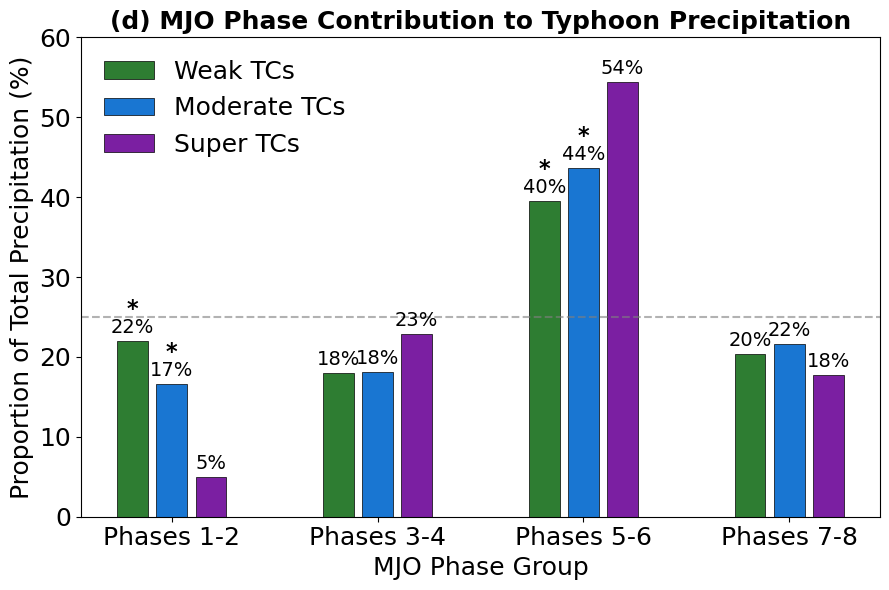

In [2]:
import os
import numpy as np
import pandas as pd
import xarray as xr
from pathlib import Path
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ==================== Global path configuration ====================
INFO_PATH = "./typhoon_output/landfall_typhoons_info.csv"
TRACKS_PATH = "./typhoon_output/landfall_typhoons_tracks.csv"
MJO_PATH = "./ERA5 MJO (1950-2024).csv"
PRECIP_DIR = "./pre"

# Typhoon intensity category mapping (using max_wind_category from the dataset)
CATEGORY_MAP = {1: 'Weak TCs', 2: 'Moderate TCs', 3: 'Super TCs'}

COLOR_MAP = {'Weak TCs': '#2E7D32', 'Moderate TCs': '#1976D2', 'Super TCs': '#7B1FA2'}

# MJO phase grouping
PHASE_GROUPS = {
    (1,2): 'Phases 1-2',
    (3,4): 'Phases 3-4',
    (5,6): 'Phases 5-6',
    (7,8): 'Phases 7-8'
}
GROUP_ORDER = ['Phases 1-2', 'Phases 3-4', 'Phases 5-6', 'Phases 7-8']

# %% [markdown]
# ### 3.1 Load and preprocess basic data

# %%
# Read typhoon landfall information, add 4-digit string code
info_df = pd.read_csv(INFO_PATH)
info_df['code_str'] = info_df['chinese_code'].apply(lambda x: f"{x:04d}")

# Read typhoon track data, add date, month, 4-digit code
tracks_df = pd.read_csv(TRACKS_PATH)
tracks_df['TIME'] = pd.to_datetime(tracks_df['TIME'])
tracks_df['code_str'] = tracks_df['chinese_code'].apply(lambda x: f"{x:04d}")
tracks_df['month'] = tracks_df['TIME'].dt.month

print(f"Total landfalling typhoons: {len(info_df)}")
print(f"Total track points: {len(tracks_df)}")

# %%
# Filter typhoons active during June-October
active_codes = tracks_df[tracks_df['month'].between(6,10)]['code_str'].unique()
print(f"Number of typhoons active in Jun-Oct: {len(active_codes)}")

# Build mapping from typhoon code to intensity category (use max_wind_category)
code_to_category = info_df.set_index('code_str')['max_wind_category'].to_dict()
code_to_catname = {code: CATEGORY_MAP.get(cat, 'Unknown') 
                   for code, cat in code_to_category.items()}

# %% [markdown]
# ### 3.2 Load MJO data and filter active events with amplitude >= 1

# %%
mjo_df = pd.read_csv(MJO_PATH)
mjo_df['date'] = pd.to_datetime(mjo_df['date'])

# Limit time range 1960-2024
mjo_df = mjo_df[(mjo_df['date'].dt.year >= 1960) & (mjo_df['date'].dt.year <= 2024)]

# Key step: keep only records with MJO amplitude >= 1
mjo_df = mjo_df[mjo_df['amplitude'] >= 1].copy()
print(f"MJO active events (amplitude >= 1) records: {len(mjo_df)}")

def phase_to_group(phase):
    """Map phases 1-8 to four groups"""
    if pd.isna(phase):
        return None
    p = int(phase)
    if p in [1,2]:
        return 'Phases 1-2'
    elif p in [3,4]:
        return 'Phases 3-4'
    elif p in [5,6]:
        return 'Phases 5-6'
    elif p in [7,8]:
        return 'Phases 7-8'
    else:
        return None

mjo_df['phase_group'] = mjo_df['phase'].apply(phase_to_group)
mjo_df = mjo_df.dropna(subset=['phase_group'])

# Build a fast date -> phase group dictionary (only dates with amplitude >= 1)
date_to_phase_group = pd.Series(mjo_df['phase_group'].values, index=mjo_df['date']).to_dict()
print(f"Available MJO active dates: {len(date_to_phase_group)}")

# %% [markdown]
# ### 3.3 Iterate over typhoon precipitation files, accumulate total precipitation (only matching MJO active days)

# %%
# Initialize accumulators: three-level dict {cat_name: {phase_group: total_precip}}
precip_accum = {cat: {group: 0.0 for group in GROUP_ORDER} 
                for cat in CATEGORY_MAP.values()}

# Process only typhoons active in June-October
for code in active_codes:
    # Get typhoon intensity category
    cat_name = code_to_catname.get(code)
    if cat_name not in CATEGORY_MAP.values():
        continue   # skip unknown categories
    
    # Precipitation file path
    nc_path = Path(PRECIP_DIR) / f"pre_{code}.nc"
    if not nc_path.exists():
        continue
    
    try:
        ds = xr.open_dataset(nc_path)
    except Exception as e:
        print(f"  Cannot read {nc_path}, skipping: {e}")
        continue
    
    # Process day by day
    for t_idx in range(len(ds.time)):
        date = pd.to_datetime(ds.time[t_idx].values)
        # Get the MJO phase group for this date (only exists if amplitude >= 1)
        phase_group = date_to_phase_group.get(date)
        if phase_group is None:
            continue   # MJO inactive or no data on this day, skip
        
        # Compute total daily precipitation (unit: mm, direct sum)
        precip_2d = ds.prec.isel(time=t_idx).values
        daily_total = np.nansum(precip_2d)
        if daily_total == 0:
            continue
        
        # Accumulate
        precip_accum[cat_name][phase_group] += daily_total
    
    ds.close()

print("\nPrecipitation accumulation completed (MJO amplitude >= 1 active days only):")
for cat, groups in precip_accum.items():
    print(f"{cat}: {groups}")


# ### 3.4 Compute proportions and plot bar chart

# %%
# Calculate the proportion (%) of each phase group within each typhoon category
precip_ratio = {}
for cat, groups in precip_accum.items():
    total = sum(groups.values())
    if total > 0:
        precip_ratio[cat] = {g: (v / total * 100) for g, v in groups.items()}
    else:
        precip_ratio[cat] = {g: 0.0 for g in groups}
        
x_labels = GROUP_ORDER
# Set figure (after increasing font sizes, adjust figsize to avoid crowding if needed)
fig, ax = plt.subplots(figsize=(9, 6))   # originally (9,6)

# x-axis positions: four phase groups
x = np.arange(len(x_labels))
width = 0.15          # bar width
gap = 0.08            # extra gap between bars
# Offsets for the three typhoon categories
offsets = [-width - gap/2, 0, width + gap/2]

# Define which bar indices (from 1) to mark with stars (adjust according to actual significance results)
star_cols = [1, 3, 5, 7]   # example, adjust as needed

# Draw bars
categories = list(CATEGORY_MAP.values())
col_counter = 1   # bar index counter

for i, cat in enumerate(categories):
    pct_vals = [precip_ratio[cat][group] for group in x_labels]
    bar_positions = x + offsets[i]
    bars = ax.bar(bar_positions, pct_vals, width,
                  color=COLOR_MAP[cat],
                  edgecolor='black', linewidth=0.5,
                  label=cat)
    
    for bar, pct in zip(bars, pct_vals):
        if pct > 0:
            x_center = bar.get_x() + bar.get_width()/2
            y_base = bar.get_height() + 0.5
            # Percentage annotation font size 14
            ax.text(x_center, y_base, f'{pct:.0f}%', ha='center', va='bottom', fontsize=14)
            
            if col_counter in star_cols:
                y_star = y_base + 2
                # Star font size 16 (can be increased if needed)
                ax.text(x_center, y_star, '*', ha='center', va='bottom',
                        fontsize=16, fontweight='bold', color='black')
            
            col_counter += 1
        else:
            col_counter += 1

# x-axis ticks
ax.set_xticks(x)
ax.set_xticklabels(x_labels, fontsize=18)   # tick label font size 18

# 25% reference line
ax.axhline(y=25, color='gray', alpha=0.6, linestyle='--', linewidth=1.5, label='_nolegend_')

# Axis labels and title (fontsize 18, title bold)
ax.set_xlabel('MJO Phase Group', fontsize=18)
ax.set_ylabel('Proportion of Total Precipitation (%)', fontsize=18)
ax.set_title('(d) MJO Phase Contribution to Typhoon Precipitation', 
             fontsize=18, fontweight='bold')

# Legend font size 18
ax.legend(['Weak TCs', 'Moderate TCs', 'Super TCs'], fontsize=18, loc='upper left', frameon=False)

# y-axis range: leave enough room for 18 pt text and stars
ax.set_ylim(0, 60)   # adjust if needed

# Tick font sizes
ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)

ax.grid(False)
for spine in ax.spines.values():
    spine.set_color('black')
    
plt.tight_layout()
plt.savefig('1d.png', dpi=600, bbox_inches='tight')
plt.show()